In [13]:
%matplotlib inline
import torch
from d2l import torch as d2l

In [14]:
# Prediction용 Dataset

class Data(d2l.DataModule):

    def __init__(
        self,
        batch_size: int = 16,
        T: int = 1000,
        num_train: int = 600,
        tau: int = 4,
    ) -> None:

        self.save_hyperparameters()

        self.time: torch.Tensor = torch.arange(
            1,
            T + 1,
            dtype=torch.float32,
        )
        
        # x = sin([0.01, 0.02, ... , 10]) + noise
        self.x: torch.Tensor = (
            torch.sin(
                0.01 * self.time
            )
            + torch.randn(T) * 0.2
        )

    def get_dataloader(
        self,
        train: bool,
    ):

        shifted_sequences: list[
            torch.Tensor
        ] = [
            self.x[
                i : self.T - self.tau + i
            ]
            for i in range(self.tau)
        ]

        self.features: torch.Tensor = (
            torch.stack(
                shifted_sequences,
                dim=1,
            )
        )

        self.labels: torch.Tensor = (
            self.x[self.tau:].reshape(
                -1,
                1,
            )
        )

        indices = (
            slice(
                0,
                self.num_train,
            )
            if train
            else slice(
                self.num_train,
                None,
            )
        )

        return self.get_tensorloader(
            (
                self.features,
                self.labels,
            ),
            train,
            indices,
        )

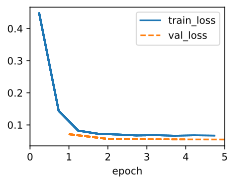

In [15]:
# Autoregressive Model 재학습

data = Data()

model = d2l.LinearRegression(
    lr=1e-2,
)

trainer = d2l.Trainer(
    max_epochs=5,
)

trainer.fit(
    model,
    data,
)

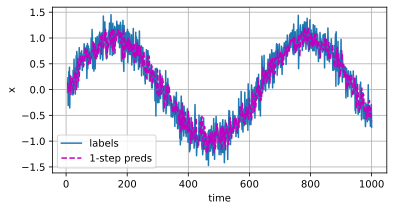

In [16]:
# One-Step Prediction

with torch.no_grad():
    onestep_preds = model(
        data.features
    ).cpu().numpy()

d2l.plot(
    data.time[data.tau:],
    [
        data.labels,
        onestep_preds,
    ],
    xlabel="time",
    ylabel="x",
    legend=[
        "labels",
        "1-step preds",
    ],
    figsize=(6, 3),
)

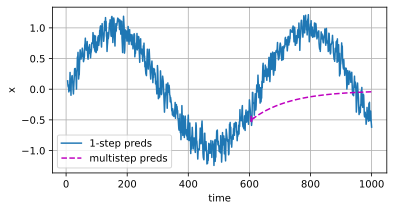

In [17]:
# Multi-Step Prediction

multistep_preds = data.x.clone()

with torch.no_grad():
    
    # index = 604, 즉, time step 605부터 예측
    # time_index: [604: 1000]
    for time_index in range(
        data.num_train + data.tau,
        data.T,
    ):
    
        # input window: x[600: 604] ~ x[995, 999]
        input_window = multistep_preds[
            time_index - data.tau
            : time_index
        ].reshape(
            1,
            -1,
        )

        prediction = model(
            input_window
        )

        multistep_preds[
            time_index
        ] = prediction.squeeze()
        
multistep_numpy = (
    multistep_preds.cpu().numpy()
)

d2l.plot(
    [
        data.time[data.tau:],
        data.time[
            data.num_train + data.tau :
        ],
    ],
    [
        onestep_preds,
        multistep_numpy[
            data.num_train + data.tau :
        ],
    ],
    xlabel="time",
    ylabel="x",
    legend=[
        "1-step preds",
        "multistep preds",
    ],
    figsize=(6, 3),
)

In [ ]:
# K-Step Prediction

def k_step_pred(
    k: int,
) -> list[torch.Tensor]:

    prediction_sequences: list[
        torch.Tensor
    ] = []

    prediction_length = (
        data.T
        - data.tau
        - k
        + 1
    )

    # 최초 tau개 Sequence는 실제 observation
    for offset in range(data.tau):

        prediction_sequences.append(
            data.x[
                offset
                : offset + prediction_length
            ]
        )

    with torch.no_grad():

        for step in range(k):

            input_features = torch.stack(
                prediction_sequences[
                    step
                    : step + data.tau
                ],
                dim=1,
            )

            predictions = model(
                input_features
            )

            prediction_sequences.append(
                predictions.reshape(-1)
            )

    # 최초 tau개 실제 Sequence를 제외하고
    # 1-step부터 k-step Prediction까지 반환
    return prediction_sequences[
        data.tau :
    ]

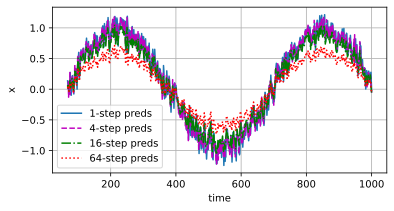

In [ ]:
# Prediction Horizon 비교

steps = (
    1,
    4,
    16,
    64,
)

predictions = k_step_pred(
    steps[-1]
)

d2l.plot(
    data.time[
        data.tau
        + steps[-1]
        - 1 :
    ],
    [
        predictions[
            k - 1
        ].cpu().numpy()
        for k in steps
    ],
    xlabel="time",
    ylabel="x",
    legend=[
        f"{k}-step preds"
        for k in steps
    ],
    figsize=(6, 3),
)